In [1]:
# Standard Libraries
import math
import pickle
import random
import numpy as np

# Data Manipulation and Visualization
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

# Quantum Computing
import pennylane as qml

# Deep Learning
import torch
from torch.autograd import Variable
from torchvision import datasets, transforms

# Utility Functions
from functools import reduce

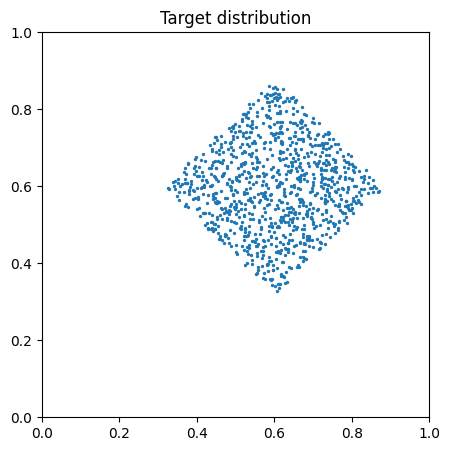

In [2]:
data_num = 1000
x = np.loadtxt(f'data/2D/biased_diamond_{data_num}_1.txt') # 바로 점 데이터를 불러옴
plt.figure(figsize=(5,5))
plt.scatter(x[:,0], x[:,1], s=2.0)
plt.title('Target distribution')
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

In [3]:
# setting torch device
ml_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(ml_device)

cpu


In [26]:
import qiskit
import qiskit_aer.noise as noise

n_qubits = 5
code_qubits = 2
noise_qubits = n_qubits - code_qubits
output_qubits = 2

n_layers = 10
print("n_qubits = {} n_layers = {}".format(n_qubits, n_layers))

def noise_device(noise_gates, noise_prob):
    my_bitflip = noise.pauli_error([('X', noise_prob), ('I', 1 - noise_prob)]) # define bitflip
    my_noise_model = noise.NoiseModel() # define noise model

    for q in range(n_qubits): # add bitflip noise to all qubits
        my_noise_model.add_quantum_error(my_bitflip, noise_gates, [q])

    dev = qml.device('qiskit.aer', wires=n_qubits, noise_model = my_noise_model)

    return dev

noise_prob = 0.01
#qml_device = noise_device(['RY'], noise_prob) # bitflip 일어날 게이트, bitflip 확률
#qml_device = qml.device("lightning.qubit", wires=n_qubits)
# qml_device = qml.device("default.mixed", wires=n_qubits) # for noisy simulation
qml_device = qml.device("default.qubit", wires=n_qubits)
# qml_device = qml.device("ionq.qpu", backend="aria-1", wires=n_qubits, shots=256)
#qml_device = qml.device("ionq.simulator", wires=n_qubits)
# dev = qml.device("ionq.qpu", wires=2)

n_qubits = 5 n_layers = 10


## QGAN 모듈을 불러오자
TODO: QGAN 모듈 고쳐서 작동하게끔 해야함.

In [27]:
import importlib
import matplotlib.pyplot as plt
from modules import QGAN  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신

# 클래스 인스턴스 생성
epoch = 300
base_dir = './정리/Scientific Reports/2D/True_np5_nl10_biased_diamond_True_Mar08_18_52_11'
param_path = f'{base_dir}/params/generator_params_epoch{epoch}.pth'

generator_initial_params = torch.load(param_path)
#generator = QGAN.QGAN2withBitFlipNoise(n_qubits, output_qubits, n_layers, generator_initial_params, qml_device, noise_prob = noise_prob, entangling = "CNOT")
generator = QGAN.QGAN2withSimpleForward(n_qubits, output_qubits, n_layers, generator_initial_params, qml_device, entangling = "CNOT")
#generator = QGAN.QGAN2(n_qubits, output_qubits, n_layers, generator_initial_params, qml_device, entangling = "CNOT")

C:\Users\minkyu\AppData\Local\Temp\ipykernel_41180\1854331249.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator_initial_params = torch.load(param_path)


Evaluation

In [ ]:
import os
import matplotlib.patches as patches
def bitwise_sums(arr):
    n = len(arr).bit_length() - 1
    return [sum(arr[i] for i in range(len(arr)) if (i >> bit) & 1) for bit in range(n)]

def run_simulation(num):
    outputs = []
    inputs = []

    for i in tqdm(range(num)):
        with torch.no_grad():
            z = np.random.uniform(-0.5, 0.5, (1, n_qubits))
            code_input = z[:, -code_qubits:].reshape(code_qubits) # 입력 z중에서 code를 추출한다.
            output_probs =  generator.forward(z).numpy().flatten()
            generator_output = bitwise_sums(output_probs)

            outputs.append(generator_output)
            inputs.append(code_input)

    inputs = np.array(inputs).reshape(-1, code_qubits)
    outputs = np.array(outputs).reshape(-1, output_qubits)

    return outputs, inputs

num = 10
outputs, inputs = run_simulation(num)
output_file_path = os.path.join(base_dir, f"output{epoch}_{num}_ionqsimul.txt")
code_file_path = os.path.join(base_dir, f"code{epoch}_{num}_ionqsimul.txt")
np.savetxt(output_file_path, outputs)
np.savetxt(code_file_path, inputs)

for code_ind in range(code_qubits):
    outputs = np.array(outputs)
    plt.figure(figsize=(6,5))
    plt.scatter(outputs[:, 0], outputs[:, 1], c=inputs[:, code_ind], cmap='RdYlBu', alpha=0.4, s=5)
    plt.colorbar()  # 색상 막대 추가
    plt.title(f'code{code_ind}-distribution (size={num})')
    plt.xlim((0, 1))
    plt.ylim((0, 1))
    ax = plt.gca()
    
    # 중심 (0.6, 0.6), 팔 길이 0.2sqrt(2)인 다이아몬드 추가
    arm = 0.2 * np.sqrt(2)
    circle = patches.Polygon([[0.6+arm, 0.6], [0.6, 0.6-arm], [0.6-arm, 0.6], [0.6, 0.6+arm]], closed=True, fill=False, edgecolor='red')
    ax.add_patch(circle)

    save_dir = os.path.join(base_dir, f'{epoch}_code{code_ind}_{num}_ionqsimul.png')
    #plt.savefig(save_dir)
    plt.show()
    plt.close()

  0%|          | 0/10 [00:02<?, ?it/s]


JobExecutionError: Job failed

In [8]:
np.savetxt(output_file_path, outputs)
np.savetxt(code_file_path, inputs)

In [94]:
noise_prob_list = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1]
epoch = 300
num = 2000
base_dir = './정리/Scientific Reports/2D/True_np5_nl10_biased_diamond_True_Mar08_18_52_11'
param_path = f'{base_dir}/params/generator_params_epoch{epoch}.pth'
generator_initial_params = torch.load(param_path)

for noise_prob in noise_prob_list:
    generator = QGAN.QGAN2withBitFlipNoise(n_qubits, output_qubits, n_layers, generator_initial_params, qml_device, noise_prob = noise_prob, entangling = "CNOT")
    
    outputs, inputs = run_simulation(num)
    output_file_path = os.path.join(base_dir, f"output{epoch}_{num}_{noise_prob}.txt")
    code_file_path = os.path.join(base_dir, f"code{epoch}_{num}_{noise_prob}.txt")
    np.savetxt(output_file_path, outputs)
    np.savetxt(code_file_path, inputs)


    for code_ind in range(code_qubits):
        outputs = np.array(outputs)
        plt.figure(figsize=(6,5))
        plt.scatter(outputs[:, 0], outputs[:, 1], c=inputs[:, code_ind], cmap='RdYlBu', alpha=0.4, s=5)
        plt.colorbar()  # 색상 막대 추가
        plt.title(f'code{code_ind}-distribution (size={num}, noise={noise_prob})')
        plt.xlim((0, 1))
        plt.ylim((0, 1))
        ax = plt.gca()
        
        # 중심 (0.6, 0.6), 팔 길이 0.2sqrt(2)인 다이아몬드 추가
        arm = 0.2 * np.sqrt(2)
        circle = patches.Polygon([[0.6+arm, 0.6], [0.6, 0.6-arm], [0.6-arm, 0.6], [0.6, 0.6+arm]], closed=True, fill=False, edgecolor='red')
        ax.add_patch(circle)

        save_dir = os.path.join(base_dir, f'{epoch}_code{code_ind}_{num}_{noise_prob}.png')
        plt.savefig(save_dir)
        plt.close()

C:\Users\minkyu\AppData\Local\Temp\ipykernel_23884\1494432953.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator_initial_params = torch.load(param_path)
100%|████

In [ ]:
noisyless